In [2]:
#!pip install pymfe

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import openml
from time import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, f1_score

from pymfe.mfe import MFE

c:\Users\Victo\Desktop\Ufal\2026.1\cc-meta-aprendizagem-2026.1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: Obter conjunto de datasets de treinamento

In [42]:
# Obtendo a lista de datasets do OpenML:
all_datasets = openml.datasets.list_datasets(output_format='dataframe')
print(f"Total de datasets no OpenML: {len(all_datasets)}")

# Filtrando os datasets com base nos critérios especificados:

filtered_datasets = all_datasets[
    (all_datasets['NumberOfInstances'] >= 200) &
    (all_datasets['NumberOfInstances'] <= 10000) &
    (all_datasets['NumberOfFeatures'] >= 2) &
    (all_datasets['NumberOfFeatures'] <= 50) &
    (all_datasets['NumberOfClasses'] >= 2) &
    (all_datasets['NumberOfClasses'] <= 6) &
    (all_datasets['NumberOfInstancesWithMissingValues'] < all_datasets['NumberOfInstances'] * 0.3) &
    (all_datasets['MinorityClassSize'] >= 20) &
    (all_datasets['NumberOfNumericFeatures'] == all_datasets['NumberOfFeatures'] - 1) &
    (all_datasets['NumberOfInstances'] * all_datasets['NumberOfFeatures'] <= 60000)
].drop_duplicates(subset='name').reset_index(drop=True)

print(f"Quantidade de datasets após filtro: {len(filtered_datasets)}")

# Removendo datasets da mesma família (baseado no nome):
filtered_datasets['family'] = filtered_datasets['name'].str.extract(r'([a-zA-Z]+)')[0]
final_datasets = filtered_datasets.drop_duplicates(subset='family').reset_index(drop=True) 
# Drop FOREX datasets:
final_datasets = final_datasets[~final_datasets['name'].str.contains('FOREX', case=False)].reset_index(drop=True)
print(f"Quantidade de datasets após remoção de famílias: {len(final_datasets)}")
# print("Datasets selecionados:")
# print(final_datasets[['name', 'NumberOfInstances', 'NumberOfFeatures', 'NumberOfClasses']])

Total de datasets no OpenML: 6403
Quantidade de datasets após filtro: 329
Quantidade de datasets após remoção de famílias: 94


In [43]:
# Baixando os datasets filtrados:

datasets = {}   # {nome: {'data': X, 'target': y}}
failed = []

for i, row in final_datasets.iterrows():
    did = int(row['did'])
    name = row['name']

    try:
        ds = openml.datasets.get_dataset(did, download_data=True,
                                         download_qualities=False,
                                         download_features_meta_data=False)
        X, y, _, _ = ds.get_data(dataset_format='dataframe',
                                 target=ds.default_target_attribute)

        unique_name = f"{name}_did{did}" # No caso de haver versões duplicadas

        datasets[unique_name] = {'data': X, 'target': y}
        print(f"[Sucesso]: {i}: {unique_name}  ({X.shape[0]}×{X.shape[1]})")

    except Exception as e:
        failed.append(name)
        print(f"[Erro]: {i}: {name}: {e}")

print("\nDownload concluído!")
print(f"Datasets carregados com sucesso: {len(datasets)}")
print(f"Número de falhas: {len(failed)}")

[Sucesso]: 0: balance-scale_did11  (625×4)
[Sucesso]: 1: breast-w_did15  (699×9)
[Sucesso]: 2: diabetes_did37  (768×8)
[Sucesso]: 3: heart-statlog_did53  (270×13)
[Sucesso]: 4: vehicle_did54  (846×18)
[Sucesso]: 5: ionosphere_did59  (351×34)
[Sucesso]: 6: oil_spill_did311  (937×49)
[Sucesso]: 7: SPECTF_did337  (349×44)
[Sucesso]: 8: prnn_synth_did464  (250×2)
[Sucesso]: 9: rmftsa_sleepdata_did679  (1024×2)
[Sucesso]: 10: fri_c3_1000_25_did715  (1000×25)
[Sucesso]: 11: pwLinear_did721  (200×10)
[Sucesso]: 12: analcatdata_supreme_did728  (4052×7)
[Sucesso]: 13: machine_cpu_did733  (209×6)
[Sucesso]: 14: space_ga_did737  (3107×6)
[Sucesso]: 15: pm10_did750  (500×7)
[Sucesso]: 16: strikes_did770  (625×6)
[Sucesso]: 17: quake_did772  (2178×3)
[Sucesso]: 18: disclosure_x_bias_did774  (662×3)
[Sucesso]: 19: bodyfat_did778  (252×14)
[Sucesso]: 20: delta_ailerons_did803  (7129×5)
[Sucesso]: 21: chscase_vine2_did814  (468×2)
[Sucesso]: 22: chatfield_4_did820  (235×12)
[Sucesso]: 23: stock_did841

## Passo 2: Avaliar performance dos classificadores nos datasets

In [44]:
# Define classifiers
from sklearn.impute import SimpleImputer


classifiers = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000),
    'Perceptron': Perceptron(random_state=42, max_iter=1000),
    'MLP': MLPClassifier(random_state=42, max_iter=1000)
}

# Store results
results = []

# Iterate through datasets
for dataset_name, dataset in datasets.items():
    print(f'Processing dataset: {dataset_name}')
    
    # Get data and target
    X = dataset['data']
    y = dataset['target']
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        print(f'Warning: Imputation failed for {dataset_name} with error: {e}')
        print('Falling back to simple imputation strategy.')
        # Use most frequent strategy for string/categorical data
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        # Fit and transform the data
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    
    # Evaluate each classifier
    for clf_name, clf in classifiers.items():
        print(f'  Evaluating {clf_name}...', end=' ')
        
        # 5-fold cross validation
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=cv, scoring='accuracy', 
                                    return_train_score=False)
        
        # Extract fold accuracies
        fold_accs = cv_results['test_score']
        
        # Create result row
        result_row = {
            'Dataset': dataset_name,
            'Classifier': clf_name,
            'acc_fold1': fold_accs[0],
            'acc_fold2': fold_accs[1],
            'acc_fold3': fold_accs[2],
            'acc_fold4': fold_accs[3],
            'acc_fold5': fold_accs[4],
            'acc_mean': fold_accs.mean(),
            'acc_stddev': fold_accs.std(),
            'train_time': cv_results['fit_time'].sum(),
            'test_time': cv_results['score_time'].sum()
        }
        
        results.append(result_row)
        print('Done')

# Create results DataFrame
performances_df = pd.DataFrame(results)

Processing dataset: balance-scale_did11
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Done
Processing dataset: breast-w_did15
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Done
Processing dataset: diabetes_did37
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

...

Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Done
Processing dataset: waveform_did47155
  Evaluating DecisionTree... Done
  Evaluating SVM... Done
  Evaluating KNN... Done
  Evaluating LogisticRegression... Done
  Evaluating Perceptron... Done
  Evaluating MLP... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the curre

Done


In [45]:
# Saving results to CSV
performances_df.to_csv('classifier_performances.csv', index=False)

In [46]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')


In [47]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,balance-scale_did11,DecisionTree,0.78400,0.78400,0.73600,0.76800,0.80000,0.77440,0.021703,0.008882,0.003440
1,balance-scale_did11,SVM,0.92000,0.91200,0.88800,0.89600,0.90400,0.90400,0.011314,0.019386,0.006748
2,balance-scale_did11,KNN,0.82400,0.81600,0.80000,0.84000,0.88800,0.83360,0.030104,0.003683,0.005514
3,balance-scale_did11,LogisticRegression,0.88000,0.88800,0.88000,0.83200,0.87200,0.87040,0.019855,0.021742,0.003292
4,balance-scale_did11,Perceptron,0.88800,0.88000,0.88000,0.83200,0.87200,0.87040,0.019855,0.009808,0.002714
...,...,...,...,...,...,...,...,...,...,...,...
559,waveform_did47155,SVM,0.81250,0.80625,0.85625,0.86875,0.81875,0.83250,0.025125,0.031121,0.016003
560,waveform_did47155,KNN,0.79375,0.78750,0.80000,0.83750,0.78750,0.80125,0.018708,0.003993,0.008159
561,waveform_did47155,LogisticRegression,0.85000,0.78125,0.85000,0.88125,0.87500,0.84750,0.035488,0.067625,0.004192
562,waveform_did47155,Perceptron,0.76250,0.71875,0.79375,0.79375,0.80000,0.77375,0.030465,0.011334,0.003715


## Passo 3: Extrair meta-features dos datasets

In [48]:
# Extract meta-features
meta_features = []

for dataset_name, dataset in list(datasets.items()):
    print(f'Extracting meta-features from {dataset_name}...', end=' ')
    
    # Get data and target
    X = dataset['data']
    y = dataset['target']

    # Handle categorical features
    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    
    # Handle missing values
    imputer = KNNImputer(n_neighbors=3)
    try:
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    except Exception as e:
        imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    
    # Encode target if necessary
    if y.dtype == 'object':
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        # Convert to numpy array if it's a pandas Series
        y = np.array(y)
    
    # Extract meta-features
    try:
        mfe = MFE(groups=['landmarking', 'general', 'statistical',
                           'model-based', 'info-theory', 'relative',
                            'clustering', 'complexity', 'itemset', 
                            'concept'],
                           summary=['median', 'min', 'max', 'mean', 
                                    'sd', 'quantiles', 'histogram'])
        # Ignore warnings during meta-feature extraction:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
        mfe.fit(X.values, y)
        ft = mfe.extract()
        # reset warnings filter to default after extraction:
        warnings.resetwarnings()        
        
        # Create result row with dataset name and meta-features
        result_row = {'dataset': dataset_name}
        
        meta_features.append(pd.DataFrame(dict(zip(ft[0], ft[1])), index=[dataset_name]))
        print('Done')
    except Exception as e:
        print(f'Error: {e}')

# Create meta-features DataFrame
meta_features_df = pd.concat(meta_features, ignore_index=False)

Extracting meta-features from balance-scale_did11... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:1567: UserWarning: It is not possible make equal discretization
  warnings.warn("It is not possible make equal discretization")
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:554: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  metafeature = callable_sum(features, **callable_args)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  

Done
Extracting meta-features from breast-w_did15... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:554: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  metafeature = callable_sum(features, **callable_args)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` t

Done
Extracting meta-features from diabetes_did37... 

...

Done
Extracting meta-features from Pumpkin_Seeds_did46951... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:554: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  metafeature = callable_sum(features, **callable_args)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` t

Done
Extracting meta-features from waveform_did47155... 

/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/pymfe/_internal.py:554: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  metafeature = callable_sum(features, **callable_args)
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/meta_learning_course/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` t

Done


In [49]:
meta_features_df

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,worst_node.quantiles.1,worst_node.quantiles.1.relative,worst_node.quantiles.2,worst_node.quantiles.2.relative,worst_node.quantiles.3,worst_node.quantiles.3.relative,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative
balance-scale_did11,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.621544,4.0,0.634921,3.0,0.673387,4.0,0.838710,5.0,0.109833,7.0
breast-w_did15,0.097222,0.152778,0.083333,0.125000,0.180556,0.194444,0.069444,0.041667,0.027778,0.027778,...,0.778571,1.0,0.828571,1.0,0.878571,1.5,0.957143,3.0,0.074922,7.0
diabetes_did37,0.767857,0.125000,0.035714,0.035714,0.000000,0.000000,0.017857,0.000000,0.000000,0.017857,...,0.649351,3.5,0.649351,2.5,0.655759,2.0,0.740260,3.0,0.029205,2.0
heart-statlog_did53,0.439394,0.295455,0.121212,0.045455,0.022727,0.037879,0.007576,0.000000,0.022727,0.007576,...,0.555556,3.0,0.555556,2.0,0.583333,2.0,0.703704,2.5,0.061605,4.0
vehicle_did54,0.606061,0.121212,0.128788,0.060606,0.022727,0.015152,0.022727,0.007576,0.000000,0.015152,...,0.360119,3.0,0.376471,3.0,0.388235,3.0,0.404762,2.0,0.024991,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hepatitis_c_virus_hcv_for_egyptian_patients_did46850,0.416667,0.037879,0.053030,0.196970,0.181818,0.075758,0.022727,0.007576,0.000000,0.007576,...,0.260870,7.0,0.274372,7.0,0.285971,7.0,0.297101,6.0,0.019974,4.0
depression_2020_did46876,0.386364,0.106061,0.128788,0.037879,0.045455,0.022727,0.015152,0.068182,0.068182,0.121212,...,0.832168,5.5,0.832168,5.5,0.832168,5.0,0.839161,5.0,0.002723,2.0
mental_health_detection_did46879,0.030303,0.045455,0.113636,0.174242,0.136364,0.113636,0.060606,0.007576,0.106061,0.212121,...,0.300926,6.5,0.324074,5.0,0.333333,3.5,0.500000,3.5,0.062006,2.0
Pumpkin_Seeds_did46951,0.803030,0.045455,0.015152,0.045455,0.000000,0.000000,0.000000,0.000000,0.030303,0.060606,...,0.548000,1.0,0.580000,1.0,0.591000,1.0,0.608000,1.0,0.027507,5.0


In [4]:
# Saving meta-features to CSV
meta_features_df.to_csv('dataset_meta_features.csv', index=True)

In [3]:
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [5]:
meta_features_df

,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,attr_conc.histogram.9,...,worst_node.quantiles.1,worst_node.quantiles.1.relative,worst_node.quantiles.2,worst_node.quantiles.2.relative,worst_node.quantiles.3,worst_node.quantiles.3.relative,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative
balance-scale_did11,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.621544,4.0,0.634921,3.0,0.673387,4.0,0.838710,5.0,0.109833,7.0
breast-w_did15,0.097222,0.152778,0.083333,0.125000,0.180556,0.194444,0.069444,0.041667,0.027778,0.027778,...,0.778571,1.0,0.828571,1.0,0.878571,1.5,0.957143,3.0,0.074922,7.0
diabetes_did37,0.767857,0.125000,0.035714,0.035714,0.000000,0.000000,0.017857,0.000000,0.000000,0.017857,...,0.649351,3.5,0.649351,2.5,0.655759,2.0,0.740260,3.0,0.029205,2.0
heart-statlog_did53,0.439394,0.295455,0.121212,0.045455,0.022727,0.037879,0.007576,0.000000,0.022727,0.007576,...,0.555556,3.0,0.555556,2.0,0.583333,2.0,0.703704,2.5,0.061605,4.0
vehicle_did54,0.606061,0.121212,0.128788,0.060606,0.022727,0.015152,0.022727,0.007576,0.000000,0.015152,...,0.360119,3.0,0.376471,3.0,0.388235,3.0,0.404762,2.0,0.024991,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hepatitis_c_virus_hcv_for_egyptian_patients_did46850,0.416667,0.037879,0.053030,0.196970,0.181818,0.075758,0.022727,0.007576,0.000000,0.007576,...,0.260870,7.0,0.274372,7.0,0.285971,7.0,0.297101,6.0,0.019974,4.0
depression_2020_did46876,0.386364,0.106061,0.128788,0.037879,0.045455,0.022727,0.015152,0.068182,0.068182,0.121212,...,0.832168,5.5,0.832168,5.5,0.832168,5.0,0.839161,5.0,0.002723,2.0
mental_health_detection_did46879,0.030303,0.045455,0.113636,0.174242,0.136364,0.113636,0.060606,0.007576,0.106061,0.212121,...,0.300926,6.5,0.324074,5.0,0.333333,3.5,0.500000,3.5,0.062006,2.0
Pumpkin_Seeds_did46951,0.803030,0.045455,0.015152,0.045455,0.000000,0.000000,0.000000,0.000000,0.030303,0.060606,...,0.548000,1.0,0.580000,1.0,0.591000,1.0,0.608000,1.0,0.027507,5.0


# Passo 4: Combinar as meta-features e as performances

In [6]:
# Loading results from CSV
performances_df = pd.read_csv('classifier_performances.csv')
# Loading meta-features from CSV
meta_features_df = pd.read_csv('dataset_meta_features.csv', index_col=0)

In [7]:
performances_df

,Dataset,Classifier,acc_fold1,acc_fold2,acc_fold3,acc_fold4,acc_fold5,acc_mean,acc_stddev,train_time,test_time
0,balance-scale_did11,DecisionTree,0.78400,0.78400,0.73600,0.76800,0.80000,0.77440,0.021703,0.008882,0.003440
1,balance-scale_did11,SVM,0.92000,0.91200,0.88800,0.89600,0.90400,0.90400,0.011314,0.019386,0.006748
2,balance-scale_did11,KNN,0.82400,0.81600,0.80000,0.84000,0.88800,0.83360,0.030104,0.003683,0.005514
3,balance-scale_did11,LogisticRegression,0.88000,0.88800,0.88000,0.83200,0.87200,0.87040,0.019855,0.021742,0.003292
4,balance-scale_did11,Perceptron,0.88800,0.88000,0.88000,0.83200,0.87200,0.87040,0.019855,0.009808,0.002714
...,...,...,...,...,...,...,...,...,...,...,...
559,waveform_did47155,SVM,0.81250,0.80625,0.85625,0.86875,0.81875,0.83250,0.025125,0.031121,0.016003
560,waveform_did47155,KNN,0.79375,0.78750,0.80000,0.83750,0.78750,0.80125,0.018708,0.003993,0.008159
561,waveform_did47155,LogisticRegression,0.85000,0.78125,0.85000,0.88125,0.87500,0.84750,0.035488,0.067625,0.004192
562,waveform_did47155,Perceptron,0.76250,0.71875,0.79375,0.79375,0.80000,0.77375,0.030465,0.011334,0.003715


In [8]:
# Reshape performances_df to have one row per dataset and the performance (acc_mean) of each classifier as a separate column
performances_df2 = performances_df.pivot(index='Dataset', columns='Classifier', values='acc_mean')
performances_df2.columns.name = None
performances_df2 = performances_df2.reset_index()
performances_df2

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186
1,CPMP-2015-runtime-classification_did41919,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905
2,CastMetal1_did1447,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608
3,CostaMadre1_did1446,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638
4,Creditability-German-Credit-Data_did46416,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000
...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577
90,waveform_did47155,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500
91,wdbc_did1510,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895
92,wilt_did40983,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063


In [9]:
# Merge performances_df2 with meta_features_df based on dataset name
meta_dataset = performances_df2.merge(
    right=meta_features_df, 
    left_on='Dataset', 
    right_index=True, 
    how='left'
)

# Reorder columns: 'Dataset' first, then meta-features, then classifiers
meta_cols = meta_features_df.columns.tolist()
classifier_cols = performances_df2.columns.drop('Dataset').tolist()
meta_dataset = meta_dataset[['Dataset'] + meta_cols + classifier_cols]

In [10]:
meta_dataset

,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.quantiles.4,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.636364,0.166667,0.045455,0.000000,0.030303,0.045455,0.030303,0.030303,0.000000,...,0.382470,3.5,0.033680,6.0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186
1,CPMP-2015-runtime-classification_did41919,0.537879,0.090909,0.151515,0.128788,0.022727,0.007576,0.030303,0.015152,0.000000,...,0.698113,5.0,0.161893,6.0,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905
2,CastMetal1_did1447,0.325758,0.128788,0.212121,0.212121,0.030303,0.015152,0.030303,0.000000,0.030303,...,0.878788,3.5,0.012300,1.5,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608
3,CostaMadre1_did1446,0.371212,0.196970,0.204545,0.121212,0.045455,0.015152,0.000000,0.030303,0.000000,...,0.896552,3.5,0.013219,1.5,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638
4,Creditability-German-Credit-Data_did46416,0.856061,0.068182,0.045455,0.007576,0.000000,0.000000,0.007576,0.007576,0.000000,...,0.700000,3.5,0.000000,2.0,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.556777,1.5,0.001054,1.5,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577
90,waveform_did47155,0.363636,0.212121,0.106061,0.075758,0.106061,0.015152,0.030303,0.045455,0.000000,...,0.500000,1.0,0.073845,7.0,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500
91,wdbc_did1510,0.833333,0.106061,0.015152,0.000000,0.000000,0.015152,0.015152,0.000000,0.000000,...,0.964912,5.5,0.101131,7.0,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895
92,wilt_did40983,0.700000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.946281,3.0,0.000650,2.0,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063


In [11]:
# Get the classifier columns (last 6 columns)
classifier_cols = meta_dataset.columns[-6:].tolist()

# Find the classifier with the best (maximum) accuracy for each dataset
meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)

C:\Users\Victo\AppData\Local\Temp\ipykernel_8712\2657989780.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  meta_dataset['Best'] = meta_dataset[classifier_cols].idxmax(axis=1)


In [12]:
meta_dataset

,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.636364,0.166667,0.045455,0.000000,0.030303,0.045455,0.030303,0.030303,0.000000,...,3.5,0.033680,6.0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression
1,CPMP-2015-runtime-classification_did41919,0.537879,0.090909,0.151515,0.128788,0.022727,0.007576,0.030303,0.015152,0.000000,...,5.0,0.161893,6.0,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905,MLP
2,CastMetal1_did1447,0.325758,0.128788,0.212121,0.212121,0.030303,0.015152,0.030303,0.000000,0.030303,...,3.5,0.012300,1.5,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608,SVM
3,CostaMadre1_did1446,0.371212,0.196970,0.204545,0.121212,0.045455,0.015152,0.000000,0.030303,0.000000,...,3.5,0.013219,1.5,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638,LogisticRegression
4,Creditability-German-Credit-Data_did46416,0.856061,0.068182,0.045455,0.007576,0.000000,0.000000,0.007576,0.007576,0.000000,...,3.5,0.000000,2.0,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000,LogisticRegression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.5,0.001054,1.5,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,DecisionTree
90,waveform_did47155,0.363636,0.212121,0.106061,0.075758,0.106061,0.015152,0.030303,0.045455,0.000000,...,1.0,0.073845,7.0,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,LogisticRegression
91,wdbc_did1510,0.833333,0.106061,0.015152,0.000000,0.000000,0.015152,0.015152,0.000000,0.000000,...,5.5,0.101131,7.0,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895,LogisticRegression
92,wilt_did40983,0.700000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.0,0.000650,2.0,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063,KNN


In [13]:
pd.DataFrame(meta_dataset['Best'].value_counts())

,count
Best,
LogisticRegression,35
DecisionTree,23
SVM,16
MLP,11
KNN,8
Perceptron,1


# Passo 5: Treinar (e avaliar) o meta-modelo

In [14]:


def train_and_evaluate_meta_model(meta_dataset):
    # Create a dictionary to store the reuslts:
    summary_of_predictions = {'Dataset':[], 'Best clf (true)':[], 'Perf of best clf (true)':[],
                           'Best clf (pred)':[], 'Perf of best clf (pred)':[]}
    loo = LeaveOneOut()
    feat_import_perf_fold = []
    y_true = meta_dataset['Best'].values
    y_pred = []

    for train_index, test_index in loo.split(meta_dataset):
        # Split the data into training and test sets
        X = meta_dataset.drop(columns=['Dataset', 'Best'] + classifier_cols) # Drop everything except meta-features
        y = meta_dataset['Best']
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train a simple classifier (e.g., Decision Tree) on the training set
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train, y_train)
        
        # Predict the best classifier for the test dataset
        y_pred.append(clf.predict(X_test)[0])
        
        # Store results in the summary dictionary
        summary_of_predictions['Dataset'].append(meta_dataset['Dataset'].iloc[test_index].values[0])
        summary_of_predictions['Best clf (true)'].append(y_test.values[0])
        summary_of_predictions['Perf of best clf (true)'].append(meta_dataset.loc[test_index, y_test.values[0]].values[0])
        summary_of_predictions['Best clf (pred)'].append(y_pred[-1])
        summary_of_predictions['Perf of best clf (pred)'].append(meta_dataset.loc[test_index, y_pred[-1]].values[0])


    # Create a DataFrame from the summary of predictions
    summary_df = pd.DataFrame(summary_of_predictions)

    # Calculate meta-model accuracy and F1-score
    meta_model_accuracy = accuracy_score(y_true, y_pred)
    meta_model_f1 = f1_score(y_true, y_pred, average='weighted')
    return summary_df, meta_model_accuracy, meta_model_f1

summary_df, meta_model_accuracy, meta_model_f1 = train_and_evaluate_meta_model(meta_dataset)
print(f'Meta-model Accuracy: {meta_model_accuracy:.2f}')
print(f'Meta-model F1-score: {meta_model_f1:.2f}')


Meta-model Accuracy: 0.43
Meta-model F1-score: 0.42


In [11]:
summary_df

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,LogisticRegression,0.382351,SVM,0.377186
1,CPMP-2015-runtime-classification_did41919,MLP,0.563594,SVM,0.521905
2,CastMetal1_did1447,SVM,0.871608,SVM,0.871608
3,CostaMadre1_did1446,LogisticRegression,0.871638,SVM,0.871638
4,Creditability-German-Credit-Data_did46416,LogisticRegression,0.750000,LogisticRegression,0.750000
...,...,...,...,...,...
89,wall-robot-navigation_did1525,DecisionTree,1.000000,SVM,0.958577
90,waveform_did47155,LogisticRegression,0.847500,MLP,0.787500
91,wdbc_did1510,LogisticRegression,0.952569,LogisticRegression,0.952569
92,wilt_did40983,KNN,0.979748,LogisticRegression,0.967971


In [12]:
# Base-level performance:
summary_df.describe()


,Perf of best clf (true),Perf of best clf (pred)
count,94.000000,94.000000
mean,0.824439,0.795715
std,0.155371,0.167102
min,0.272924,0.257040
25%,0.758788,0.715175
50%,0.858395,0.844350
75%,0.936250,0.922649
max,1.000000,1.000000


In [13]:
final_summary = pd.concat([performances_df2, summary_df], axis=1)
# Drop second 'Dataset' column
idx_to_drop = list(final_summary.columns).index('Dataset', 1)  # Find the index of the second 'Dataset' column
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression,0.382351,SVM,0.377186
1,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905,MLP,0.563594,SVM,0.521905
2,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608,SVM,0.871608,SVM,0.871608
3,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638,LogisticRegression,0.871638,SVM,0.871638
4,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000,LogisticRegression,0.750000,LogisticRegression,0.750000
...,...,...,...,...,...,...,...,...,...,...
89,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,DecisionTree,1.000000,SVM,0.958577
90,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,LogisticRegression,0.847500,MLP,0.787500
91,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895,LogisticRegression,0.952569,LogisticRegression,0.952569
92,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063,KNN,0.979748,LogisticRegression,0.967971


<Axes: >

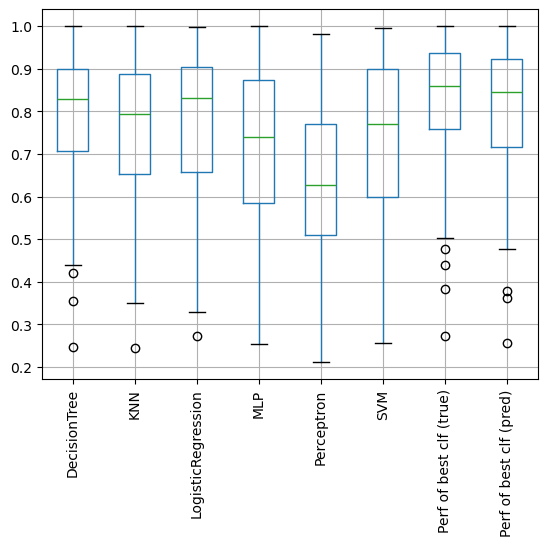

In [14]:
final_summary.boxplot(rot=90)

# Seleção de meta-features

## Algoritmo Genético:

In [15]:
classifier_cols = [c for c in meta_dataset.columns if c in ['DecisionTree', 'SVM', 'KNN',
                                                           'LogisticRegression', 'Perceptron', 'MLP']]
meta_feature_cols = [c for c in meta_dataset.columns if c not in ['Dataset', 'Best'] + classifier_cols]

def evaluate_feature_subset(feature_subset):
    X = meta_dataset[feature_subset]
    y = meta_dataset['Best'].values
    loo = LeaveOneOut()
    y_pred = []
    for train_idx, test_idx in loo.split(X):
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X.iloc[train_idx], y[train_idx])
        y_pred.append(clf.predict(X.iloc[test_idx])[0])
    return f1_score(y, y_pred, average='weighted')

def random_individual():
    ind = np.random.choice([0, 1], size=len(meta_feature_cols), p=[0.5, 0.5])
    if ind.sum() == 0:
        ind[np.random.randint(len(ind))] = 1
    return ind

def decode_individual(ind):
    return [meta_feature_cols[i] for i, bit in enumerate(ind) if bit == 1]

fitness_cache = {}
def fitness(individual):
    key = tuple(individual.tolist())
    if key not in fitness_cache:
        fitness_cache[key] = evaluate_feature_subset(decode_individual(individual))
    return fitness_cache[key]

def tournament_selection(population, scores, k=3):
    contenders = np.random.choice(len(population), size=k, replace=False)
    best_idx = max(contenders, key=lambda idx: scores[idx])
    return population[best_idx].copy()

def one_point_crossover(parent1, parent2):
    if len(parent1) <= 1:
        return parent1.copy(), parent2.copy()
    point = np.random.randint(1, len(parent1))
    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])
    return child1, child2

def mutate(individual, mutation_prob=0.05):
    for i in range(len(individual)):
        if np.random.rand() < mutation_prob:
            individual[i] = 1 - individual[i]
    if individual.sum() == 0:
        individual[np.random.randint(len(individual))] = 1

np.random.seed(42)

pop_size = 14
n_generations = 30
crossover_prob = 0.8
mutation_prob = 0.05
elitism = 2

population = [random_individual() for _ in range(pop_size)]
scores = [fitness(ind) for ind in population]

history = []
for generation in range(n_generations):
    ranked = sorted(zip(population, scores), key=lambda x: x[1], reverse=True)
    best_individual, best_score = ranked[0]
    mean_score = np.mean(scores)
    history.append({
        'generation': generation,
        'best_f1': best_score,
        'mean_f1': mean_score,
        'features_count': int(best_individual.sum())
    })
    print(f'Generation {generation}: best F1 = {best_score:.4f}, mean F1 = {mean_score:.4f}, features = {int(best_individual.sum())}')

    new_population = [ind.copy() for ind, _ in ranked[:elitism]]

    while len(new_population) < pop_size:
        parent1 = tournament_selection(population, scores)
        parent2 = tournament_selection(population, scores)
        if np.random.rand() < crossover_prob:
            child1, child2 = one_point_crossover(parent1, parent2)
        else:
            child1, child2 = parent1.copy(), parent2.copy()
        mutate(child1, mutation_prob)
        mutate(child2, mutation_prob)
        new_population.extend([child1, child2])

    population = new_population[:pop_size]
    scores = [fitness(ind) for ind in population]

best_idx = int(np.argmax(scores))
best_individual = population[best_idx]
selected_meta_features_ga = decode_individual(best_individual)
best_meta_model_f1 = scores[best_idx]

print('\nBest feature subset found:')
print(selected_meta_features_ga)
print(f'Best meta-model F1 = {best_meta_model_f1:.4f}')
print(f'Number of selected meta-features = {len(selected_meta_features_ga)}')

history_df = pd.DataFrame(history)
history_df

Generation 0: best F1 = 0.5044, mean F1 = 0.4056, features = 669
Generation 1: best F1 = 0.5044, mean F1 = 0.4428, features = 669
Generation 2: best F1 = 0.5044, mean F1 = 0.4453, features = 669
Generation 3: best F1 = 0.5044, mean F1 = 0.4498, features = 669
Generation 4: best F1 = 0.5422, mean F1 = 0.4291, features = 714
Generation 5: best F1 = 0.5422, mean F1 = 0.4790, features = 714
Generation 6: best F1 = 0.5471, mean F1 = 0.4778, features = 679
Generation 7: best F1 = 0.6349, mean F1 = 0.4986, features = 694
Generation 8: best F1 = 0.6349, mean F1 = 0.5071, features = 694
Generation 9: best F1 = 0.6349, mean F1 = 0.5361, features = 694
Generation 10: best F1 = 0.6349, mean F1 = 0.5349, features = 694
Generation 11: best F1 = 0.6349, mean F1 = 0.5348, features = 694
Generation 12: best F1 = 0.6349, mean F1 = 0.5461, features = 694
Generation 13: best F1 = 0.6349, mean F1 = 0.5376, features = 694
Generation 14: best F1 = 0.6349, mean F1 = 0.5648, features = 694
Generation 15: best 

KeyboardInterrupt: 

In [16]:
selected_meta_features_ga

['attr_conc.histogram.3',
 'attr_conc.histogram.7',
 'attr_conc.mean',
 'attr_conc.min',
 'attr_conc.quantiles.1',
 'attr_conc.quantiles.2',
 'attr_conc.quantiles.3',
 'attr_conc.quantiles.4',
 'attr_conc.sd',
 'attr_ent.histogram.0',
 'attr_ent.histogram.1',
 'attr_ent.histogram.2',
 'attr_ent.histogram.3',
 'attr_ent.histogram.4',
 'attr_ent.histogram.7',
 'attr_ent.histogram.9',
 'attr_ent.max',
 'attr_ent.mean',
 'attr_ent.median',
 'attr_ent.min',
 'attr_ent.quantiles.0',
 'attr_ent.quantiles.1',
 'attr_ent.quantiles.2',
 'attr_ent.quantiles.4',
 'attr_ent.sd',
 'attr_to_inst',
 'best_node.histogram.0',
 'best_node.histogram.1',
 'best_node.histogram.5.relative',
 'best_node.histogram.6',
 'best_node.histogram.6.relative',
 'best_node.histogram.7.relative',
 'best_node.max.relative',
 'best_node.mean',
 'best_node.mean.relative',
 'best_node.median',
 'best_node.min',
 'best_node.min.relative',
 'best_node.quantiles.0.relative',
 'best_node.quantiles.1',
 'best_node.quantiles.1.re

In [18]:
meta_dataset

,Dataset,attr_conc.histogram.0,attr_conc.histogram.1,attr_conc.histogram.2,attr_conc.histogram.3,attr_conc.histogram.4,attr_conc.histogram.5,attr_conc.histogram.6,attr_conc.histogram.7,attr_conc.histogram.8,...,worst_node.quantiles.4.relative,worst_node.sd,worst_node.sd.relative,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Best
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.636364,0.166667,0.045455,0.000000,0.030303,0.045455,0.030303,0.030303,0.000000,...,3.5,0.033680,6.0,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,LogisticRegression
1,CPMP-2015-runtime-classification_did41919,0.537879,0.090909,0.151515,0.128788,0.022727,0.007576,0.030303,0.015152,0.000000,...,5.0,0.161893,6.0,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905,MLP
2,CastMetal1_did1447,0.325758,0.128788,0.212121,0.212121,0.030303,0.015152,0.030303,0.000000,0.030303,...,3.5,0.012300,1.5,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608,SVM
3,CostaMadre1_did1446,0.371212,0.196970,0.204545,0.121212,0.045455,0.015152,0.000000,0.030303,0.000000,...,3.5,0.013219,1.5,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638,LogisticRegression
4,Creditability-German-Credit-Data_did46416,0.856061,0.068182,0.045455,0.007576,0.000000,0.000000,0.007576,0.007576,0.000000,...,3.5,0.000000,2.0,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000,LogisticRegression
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.5,0.001054,1.5,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,DecisionTree
90,waveform_did47155,0.363636,0.212121,0.106061,0.075758,0.106061,0.015152,0.030303,0.045455,0.000000,...,1.0,0.073845,7.0,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,LogisticRegression
91,wdbc_did1510,0.833333,0.106061,0.015152,0.000000,0.000000,0.015152,0.015152,0.000000,0.000000,...,5.5,0.101131,7.0,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895,LogisticRegression
92,wilt_did40983,0.700000,0.100000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.0,0.000650,2.0,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063,KNN


In [19]:
# Performance apenas com as meta-features calculadas por dataset ou as meta-features usadas no Exemplo 3:
mfs_exemplo3 = ['attr_conc.mean','attr_ent.mean','attr_to_inst','can_cor.mean','cat_to_num','ch','class_conc.mean','class_ent','cor.mean','cov.mean','eigenvalues.mean','eq_num_attr','freq_class.mean','g_mean.mean','gravity','h_mean.mean','inst_to_attr','int','iq_range.mean','joint_ent.mean','kurtosis.mean','lh_trace','mad.mean','max.mean','mean.mean','median.mean','min.mean','mut_inf.mean','nr_attr','nr_bin','nr_cat','nr_class','nr_cor_attr','nr_disc','nr_inst','nr_norm','nr_num','nr_outliers','nre','ns_ratio','num_to_cat','p_trace','pb','range.mean','roy_root','sc','sd.mean','sd_ratio','sil','skewness.mean','sparsity.mean','t_mean.mean','var.mean','vdb','vdu','w_lambda']
summary_df_mfex3, meta_model_accuracy_mfex3, meta_model_f1_mfex3 = train_and_evaluate_meta_model(meta_dataset[['Dataset'] + mfs_exemplo3 + classifier_cols + ['Best']])
print(f'Meta-model Accuracy: {meta_model_accuracy_mfex3:.2f}')
print(f'Meta-model F1-score: {meta_model_f1_mfex3:.2f}')

Meta-model Accuracy: 0.41
Meta-model F1-score: 0.40


In [20]:
# Performance com todas as meta-features:
summary_df_all, meta_model_accuracy_all, meta_model_f1_all = train_and_evaluate_meta_model(meta_dataset)
print(f'Meta-model Accuracy: {meta_model_accuracy_all:.2f}')
print(f'Meta-model F1-score: {meta_model_f1_all:.2f}')

Meta-model Accuracy: 0.41
Meta-model F1-score: 0.41


In [21]:
# Performance com as meta-features selecionadas pelo GA:
summary_df_feature_sel, meta_model_accuracy_sel, meta_model_f1_sel = train_and_evaluate_meta_model(meta_dataset[['Dataset'] + selected_meta_features_ga + classifier_cols + ['Best']])
print(f'Meta-model Accuracy: {meta_model_accuracy_sel:.2f}')
print(f'Meta-model F1-score: {meta_model_f1_sel:.2f}')

Meta-model Accuracy: 0.64
Meta-model F1-score: 0.64


In [129]:
summary_df_feature_sel

,Dataset,Best clf (true),Perf of best clf (true),Best clf (pred),Perf of best clf (pred)
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,LogisticRegression,0.382351,LogisticRegression,0.382351
1,CPMP-2015-runtime-classification_did41919,MLP,0.563594,KNN,0.497125
2,CastMetal1_did1447,SVM,0.871608,SVM,0.871608
3,CostaMadre1_did1446,LogisticRegression,0.871638,SVM,0.871638
4,Creditability-German-Credit-Data_did46416,LogisticRegression,0.750000,LogisticRegression,0.750000
...,...,...,...,...,...
89,wall-robot-navigation_did1525,DecisionTree,1.000000,SVM,0.958577
90,waveform_did47155,LogisticRegression,0.847500,LogisticRegression,0.847500
91,wdbc_did1510,LogisticRegression,0.952569,LogisticRegression,0.952569
92,wilt_did40983,KNN,0.979748,LogisticRegression,0.967971


In [26]:
summary_df_all = summary_df_all[['Best clf (pred)', 'Perf of best clf (pred)']].rename(columns={'Best clf (pred)': 'Best clf (pred) (all features)', 'Perf of best clf (pred)': 'Perf of best clf (pred) (all features)'})
summary_sel = summary_df_feature_sel[['Best clf (pred)', 'Perf of best clf (pred)']].rename(columns={'Best clf (pred)': 'Best clf (pred) (feat sel GA)', 'Perf of best clf (pred)': 'Perf of best clf (pred) (feat sel GA)'})   
summary_mfex3 = summary_df_mfex3[['Best clf (pred)', 'Perf of best clf (pred)']].rename(columns={'Best clf (pred)': 'Best clf (pred) (mf ex3)', 'Perf of best clf (pred)': 'Perf of best clf (pred) (mf ex3)'})  

In [30]:
final_summary = pd.concat([performances_df2, summary_df_all, summary_mfex3, summary_sel, ], axis=1)
final_summary = final_summary.drop(columns=final_summary.columns[idx_to_drop], axis=1)
final_summary

,Dataset,DecisionTree,KNN,LogisticRegression,MLP,Perceptron,SVM,Perf of best clf (pred) (all features),Best clf (pred) (mf ex3),Perf of best clf (pred) (mf ex3),Best clf (pred) (feat sel GA),Perf of best clf (pred) (feat sel GA)
0,Apple_Stock_Price_Trends_(2014-2023)_did46420,0.353728,0.350561,0.382351,0.351341,0.351368,0.377186,0.377186,DecisionTree,0.353728,SVM,0.377186
1,CPMP-2015-runtime-classification_did41919,0.419389,0.497125,0.561743,0.563594,0.493513,0.521905,0.521905,MLP,0.563594,MLP,0.563594
2,CastMetal1_did1447,0.807459,0.859441,0.859580,0.663497,0.862378,0.871608,0.871608,LogisticRegression,0.859580,SVM,0.871608
3,CostaMadre1_did1446,0.824181,0.858136,0.871638,0.636554,0.280904,0.871638,0.871638,SVM,0.871638,SVM,0.871638
4,Creditability-German-Credit-Data_did46416,0.681000,0.648000,0.750000,0.700000,0.611000,0.711000,0.750000,LogisticRegression,0.750000,LogisticRegression,0.750000
...,...,...,...,...,...,...,...,...,...,...,...,...
89,wall-robot-navigation_did1525,1.000000,0.984420,0.921376,0.984604,0.834680,0.958577,0.958577,LogisticRegression,0.921376,SVM,0.958577
90,waveform_did47155,0.717500,0.801250,0.847500,0.787500,0.773750,0.832500,0.787500,Perceptron,0.773750,DecisionTree,0.717500
91,wdbc_did1510,0.910402,0.935010,0.952569,0.927993,0.880640,0.913895,0.952569,LogisticRegression,0.952569,LogisticRegression,0.952569
92,wilt_did40983,0.977062,0.979748,0.967971,0.973136,0.933660,0.946063,0.967971,LogisticRegression,0.967971,LogisticRegression,0.967971


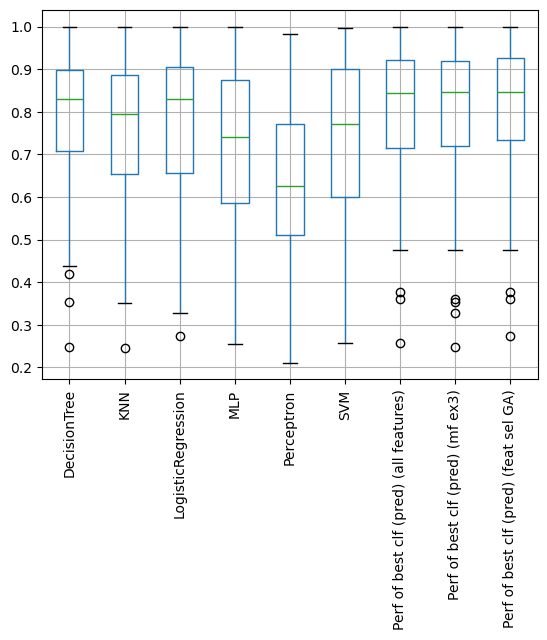

In [31]:
plt.close()
final_summary.boxplot(rot=90)
plt.show()

In [18]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Configurações de Penalidade
# 0.05 significa que o AG está disposto a trocar 5% de F1 para remover metade das features.
# Ajuste para mais (ex: 0.1) se quiser ainda menos features.
PARSIMONY_WEIGHT = 0.05 

# ==========================================
# 1. FUNÇÕES DE AVALIAÇÃO OTIMIZADAS
# ==========================================
fitness_cache = {}

def evaluate_feature_subset(feature_subset):
    if len(feature_subset) == 0:
        return 0.0
        
    X = meta_dataset[feature_subset]
    y = meta_dataset['Best']
    
    # Usamos DecisionTree pois é sensível a features irrelevantes (bom para seleção)
    clf = DecisionTreeClassifier(random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    try:
        y_pred = cross_val_predict(clf, X, y, cv=cv, n_jobs=-1)
        return f1_score(y, y_pred, average='weighted')
    except:
        return 0.0

def fitness(individual):
    key = tuple(individual.tolist())
    if key not in fitness_cache:
        subset = [meta_feature_cols[i] for i, bit in enumerate(individual) if bit == 1]
        n_features = len(subset)
        total_features = len(meta_feature_cols)
        
        # 1. Calcula o F1 puro
        f1 = evaluate_feature_subset(subset)
        
        # 2. Calcula a penalidade de tamanho (razão de features usadas)
        # Quanto mais features, maior a penalidade.
        size_penalty = (n_features / total_features) * PARSIMONY_WEIGHT
        
        # Fitness final: F1 menos a penalidade de tamanho
        fitness_val = f1 - size_penalty
        
        # Guardamos o F1 real e o valor de fitness
        fitness_cache[key] = (fitness_val, f1)
        
    return fitness_cache[key]

# ==========================================
# 2. OPERADORES PARA "POUCAS FEATURES"
# ==========================================
def random_lean_individual():
    """Inicia indivíduos com pouquíssimas features (aprox. 15% de probabilidade)"""
    ind = np.random.choice([0, 1], size=len(meta_feature_cols), p=[0.85, 0.15])
    if ind.sum() == 0:
        ind[np.random.randint(len(ind))] = 1
    return ind

def mutate_sparse(individual, mutation_prob=0.03):
    """Mutação mais conservadora para não inflar o número de features"""
    for i in range(len(individual)):
        if np.random.rand() < mutation_prob:
            # Se for 1, tem mais chance de virar 0 do que o contrário (limpeza)
            if individual[i] == 1:
                individual[i] = 0 if np.random.rand() < 0.7 else 1
            else:
                individual[i] = 1 if np.random.rand() < 0.3 else 0
    if individual.sum() == 0:
        individual[np.random.randint(len(individual))] = 1

# ==========================================
# 3. LOOP DO ALGORITMO GENÉTICO
# ==========================================
pop_size = 20
n_generations = 40
elitism = 2

population = [random_lean_individual() for _ in range(pop_size)]
# Cada score agora é uma tupla (fitness_com_penalidade, f1_real)
scores_data = Parallel(n_jobs=-1)(delayed(fitness)(ind) for ind in population)

history = []

print(f"Iniciando AG focado em Redução de Dimensionalidade (Peso: {PARSIMONY_WEIGHT})")
print("-" * 75)

for gen in range(n_generations):
    # Ordena pelo fitness_val (índice 0 da tupla)
    ranked = sorted(zip(population, scores_data), key=lambda x: x[1][0], reverse=True)
    
    best_ind, (best_fit, best_f1_real) = ranked[0]
    n_feat = int(best_ind.sum())
    
    history.append({
        'gen': gen, 'f1': best_f1_real, 'features': n_feat
    })
    
    print(f"Geração {gen:02d} | F1 Real: {best_f1_real:.4f} | Features: {n_feat}/{len(meta_feature_cols)} | Fitness: {best_fit:.4f}")

    # Seleção e Evolução
    new_pop = [ind.copy() for ind, _ in ranked[:elitism]]
    
    while len(new_pop) < pop_size:
        # Torneio baseado no fitness_val
        p1 = population[max(np.random.choice(len(population), 3), key=lambda i: scores_data[i][0])]
        p2 = population[max(np.random.choice(len(population), 3), key=lambda i: scores_data[i][0])]
        
        c1, c2 = p1.copy(), p2.copy()
        if np.random.rand() < 0.8:
            point = np.random.randint(1, len(c1))
            c1 = np.concatenate([p1[:point], p2[point:]])
            c2 = np.concatenate([p2[:point], p1[point:]])
            
        mutate_sparse(c1)
        mutate_sparse(c2)
        new_pop.extend([c1, c2])

    population = new_pop[:pop_size]
    scores_data = Parallel(n_jobs=-1)(delayed(fitness)(ind) for ind in population)

# ==========================================
# 4. RESULTADO FINAL
# ==========================================
best_idx = np.argmax([s[0] for s in scores_data])
final_ind = population[best_idx]
final_features = [meta_feature_cols[i] for i, bit in enumerate(final_ind) if bit == 1]

print("-" * 75)
print(f"CONCLUÍDO: O AG encontrou {len(final_features)} atributos.")
print(f"F1-Score Estimado: {scores_data[best_idx][1]:.4f}")
print(f"Atributos Selecionados: {final_features}")

Iniciando AG focado em Redução de Dimensionalidade (Peso: 0.05)
---------------------------------------------------------------------------
Geração 00 | F1 Real: 0.4290 | Features: 194/1385 | Fitness: 0.4220
Geração 01 | F1 Real: 0.4567 | Features: 202/1385 | Fitness: 0.4494
Geração 02 | F1 Real: 0.4567 | Features: 202/1385 | Fitness: 0.4494
Geração 03 | F1 Real: 0.4567 | Features: 202/1385 | Fitness: 0.4494
Geração 04 | F1 Real: 0.4715 | Features: 238/1385 | Fitness: 0.4629
Geração 05 | F1 Real: 0.4715 | Features: 238/1385 | Fitness: 0.4629
Geração 06 | F1 Real: 0.4715 | Features: 238/1385 | Fitness: 0.4629
Geração 07 | F1 Real: 0.4715 | Features: 238/1385 | Fitness: 0.4629
Geração 08 | F1 Real: 0.4803 | Features: 237/1385 | Fitness: 0.4717
Geração 09 | F1 Real: 0.4803 | Features: 237/1385 | Fitness: 0.4717
Geração 10 | F1 Real: 0.4902 | Features: 245/1385 | Fitness: 0.4813
Geração 11 | F1 Real: 0.4902 | Features: 245/1385 | Fitness: 0.4813
Geração 12 | F1 Real: 0.4902 | Features: 245